In [1]:
import pandas as pd

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

print(f"Train: {X_train.shape}, fraud={y_train.sum()}")
print(f"Test:  {X_test.shape}, fraud={y_test.sum()}")

Train: (227845, 30), fraud=394
Test:  (56962, 30), fraud=98


In [2]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

def evaluate_model(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    
    auprc = average_precision_score(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    print(f"\n{'='*50}")
    print(f"{name}  (threshold={threshold})")
    print(f"{'='*50}")
    print(f"AUPRC:   {auprc:.4f}   <- primary metric")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Legit', 'Fraud'])}")
    
    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion matrix:\n{cm}")
    print(f"  -> Caught {cm[1,1]}/{cm[1,1]+cm[1,0]} frauds, {cm[0,1]} false alarms")
    
    return {"name": name, "auprc": auprc, "roc_auc": roc_auc, "y_proba": y_proba}

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
results_lr = evaluate_model("Logistic Regression", y_test, lr_proba)


Logistic Regression  (threshold=0.5)
AUPRC:   0.7190   <- primary metric
ROC-AUC: 0.9721

              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Confusion matrix:
[[55478  1386]
 [    8    90]]
  -> Caught 90/98 frauds, 1386 false alarms


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', 
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)  # no scaling needed

rf_proba = rf.predict_proba(X_test)[:, 1]
results_rf = evaluate_model("Random Forest", y_test, rf_proba)


Random Forest  (threshold=0.5)
AUPRC:   0.8629   <- primary metric
ROC-AUC: 0.9573

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix:
[[56855     9]
 [   20    78]]
  -> Caught 78/98 frauds, 9 false alarms


In [5]:
import xgboost as xgb

# scale_pos_weight tells XGBoost how much more to weight the rare class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
results_xgb = evaluate_model("XGBoost", y_test, xgb_proba)

scale_pos_weight = 577.3

XGBoost  (threshold=0.5)
AUPRC:   0.8791   <- primary metric
ROC-AUC: 0.9726

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix:
[[56852    12]
 [   17    81]]
  -> Caught 81/98 frauds, 12 false alarms


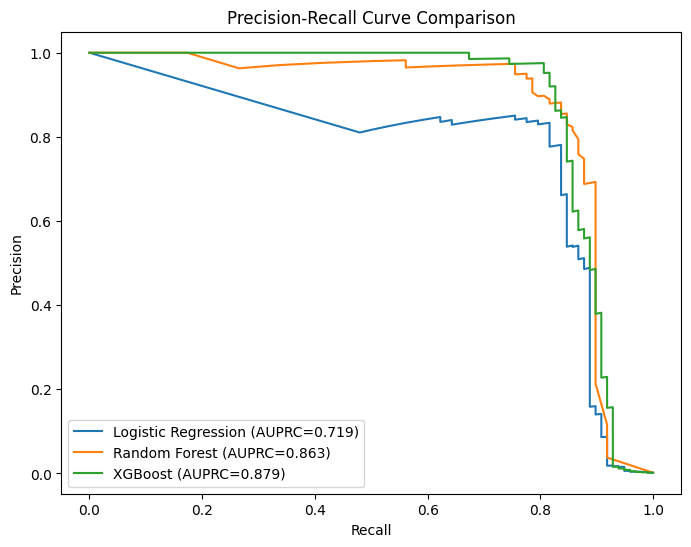

In [6]:
plt.figure(figsize=(8, 6))
for res in [results_lr, results_rf, results_xgb]:
    precision, recall, _ = precision_recall_curve(y_test, res['y_proba'])
    plt.plot(recall, precision, label=f"{res['name']} (AUPRC={res['auprc']:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.savefig("../outputs/02_pr_curve_comparison.png", dpi=150, bbox_inches='tight')
plt.show()